# Phase 5: Ensembling & Submission

In this phase, we focus on Gradient Boosted Trees.

We will train **LightGBM**, **CatBoost**, and **XGBoost** simultaneously. Each algorithm builds its decision trees using slightly different mathematical approaches, so they will make different mistakes then we take the average of their predictions (Ensembling), cancel out those mistakes and achieve a much lower Log Loss.

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
# import catboost as cb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import mlflow
import sys

sys.path.append('../')
from src.metrics import zindi_score


# mlflow.set_tracking_uri('sqlite:///../mlflow.db')
# mlflow.set_experiment('Zindi_Liquidity_Stress')

## 1. Load Data
we are not scaling the data with StandardScaler here since Tree models do not care about scaling that much but we One-Hot Encode the categorical text columns (like `gender`, `region`) because standard tree algorithms cannot process raw strings.

In [10]:
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
test_df = pd.read_parquet('../data/features/test_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')
raw_test = pd.read_csv('../data/Test.csv')

target = raw_train['liquidity_stress_next_30d']
X = train_df.drop(columns=['ID', 'liquidity_stress_next_30d'])
X_test = test_df.drop(columns=['ID'])

# One-Hot Encoding the categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    print(f"Encoding Categorical Columns: {list(cat_cols)}")
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    
    # ensure train and test have the exact same columns after encoding
    X_test = X_test.reindex(columns=X.columns, fill_value=0)

# convert all booleans from get_dummies to integers (0/1)
X = X.astype({col: int for col in X.select_dtypes(include=bool).columns})
X_test = X_test.astype({col: int for col in X_test.select_dtypes(include=bool).columns})

print(f"Training Features: {X.shape}")
print(f"Testing Features: {X_test.shape}")

Training Features: (40000, 444)
Testing Features: (30000, 444)


In [11]:
# run 5-Fold Cross Validation for each model and collect their predictions.

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# arrays to hold Out-Of-Fold (OOF) predictions (for local scoring)
oof_lgb = np.zeros(len(X))
oof_cb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

# arrays to hold Test predictions (for final submission)
test_lgb = np.zeros(len(X_test))
test_cb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

# the Best parameters found by Optuna in Phase 6 Tuning
lgb_params = {'learning_rate': 0.07000857701607659, 'num_leaves': 27, 'max_depth': 8, 'min_child_samples': 71, 'subsample': 0.7227032899255299, 'colsample_bytree': 0.8012769608390673, 'n_estimators': 500, 'random_state': 42, 'verbosity': -1}
cb_params = {'learning_rate': 0.19775545782423468, 'depth': 5, 'l2_leaf_reg': 0.5290629979609613, 'subsample': 0.6633141772092477, 'iterations': 500, 'random_seed': 42, 'verbose': False}
xgb_params = {'learning_rate': 0.05612762846223619, 'max_depth': 9, 'min_child_weight': 14, 'subsample': 0.7984977991980712, 'colsample_bytree': 0.873957633262947, 'n_estimators': 500, 'random_state': 42, 'verbosity': 0}

print("Starting 5-Fold Training for the Ensemble...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, target)):
    print(f"\n--- Fold {fold+1} ---")
    X_train, y_train = X.iloc[train_idx], target.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], target.iloc[val_idx]
    
    # 1. LightGBM
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_train, y_train)
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    test_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_FOLDS
    print("LightGBM Fold Complete.")
    
    # # 2. CatBoost
    # model_cb = cb.CatBoostClassifier(**cb_params)
    # model_cb.fit(X_train, y_train)
    # oof_cb[val_idx] = model_cb.predict_proba(X_val)[:, 1]
    # test_cb += model_cb.predict_proba(X_test)[:, 1] / N_FOLDS
    # print("CatBoost Fold Complete.")

    # 3. XGBoost
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_train, y_train)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    test_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_FOLDS
    print("XGBoost Fold Complete.")

Starting 5-Fold Training for the Ensemble...

--- Fold 1 ---
LightGBM Fold Complete.
XGBoost Fold Complete.

--- Fold 2 ---
LightGBM Fold Complete.
XGBoost Fold Complete.

--- Fold 3 ---
LightGBM Fold Complete.
XGBoost Fold Complete.

--- Fold 4 ---
LightGBM Fold Complete.
XGBoost Fold Complete.

--- Fold 5 ---
LightGBM Fold Complete.
XGBoost Fold Complete.


## 3. Blending (The Ensemble)
We will evaluate each model individually, and then evaluate a blended average of all three.

In [12]:
print("\n--- ENSEMBLE SCORE ---")
# apply the Weighted Average Blend to favor the stronger model, LightGBM
oof_blend = (oof_lgb * 0.5) + (oof_cb * 0.25) + (oof_xgb * 0.25)
blend_loss, blend_auc = zindi_score(target, oof_blend)
print(f"BLEND    -> LogLoss: {blend_loss:.4f} | AUC: {blend_auc:.4f}")



--- ENSEMBLE SCORE ---
--- Model Evaluation ---
Log Loss: 0.2885
ROC-AUC: 0.8885
------------------------
BLEND    -> LogLoss: 0.2885 | AUC: 0.8885


## 4. Generate Zindi Submission

In [13]:
# Apply the same weighted average to the test predictions
test_blend = (test_lgb * 0.5) + (test_cb * 0.25) + (test_xgb * 0.25)

submission = pd.DataFrame({
    'ID': raw_test['ID'],
    'liquidity_stress_next_30d': test_blend
})

# Save to CSV
submission.to_csv('../submissions/submission1.csv', index=False)
print("Submission file saved")

Submission file saved


## Overfitting Check

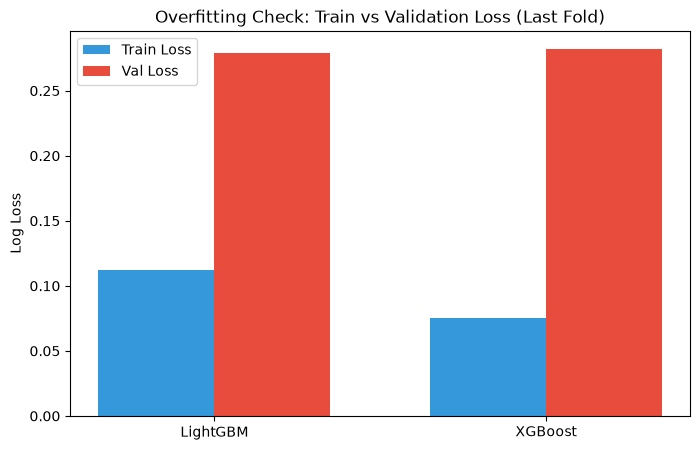

LightGBM - Train: 0.1124, Val: 0.2790, Gap: 0.1666
XGBoost - Train: 0.0751, Val: 0.2818, Gap: 0.2067


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

def check_overfitting():
    try:
        models_to_check = {}
        if 'model_lgb' in globals(): models_to_check['LightGBM'] = model_lgb
        if 'model_cb' in globals(): models_to_check['CatBoost'] = model_cb
        if 'model_xgb' in globals(): models_to_check['XGBoost'] = model_xgb
        if 'model' in globals() and 'LGBM' in str(type(model)): models_to_check['LightGBM'] = model
        
        if not models_to_check:
            print("No standard models found in memory to check.")
            return
            
        if 'X_train' not in globals() or 'X_val' not in globals():
            print("X_train or X_val not found in memory.")
            return
            
        train_losses = []
        val_losses = []
        names = []
        
        for name, m in models_to_check.items():
            train_p = m.predict_proba(X_train)[:, 1]
            val_p = m.predict_proba(X_val)[:, 1]
            train_losses.append(log_loss(y_train, train_p))
            val_losses.append(log_loss(y_val, val_p))
            names.append(name)
            
        x = range(len(names))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='#3498db')
        ax.bar([i + width/2 for i in x], val_losses, width, label='Val Loss', color='#e74c3c')
        
        ax.set_ylabel('Log Loss')
        ax.set_title('Overfitting Check: Train vs Validation Loss (Last Fold)')
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.legend()
        plt.show()
        
        for i, name in enumerate(names):
            print(f"{name} - Train: {train_losses[i]:.4f}, Val: {val_losses[i]:.4f}, Gap: {val_losses[i] - train_losses[i]:.4f}")
            
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_overfitting()